In [ ]:
import pandas as pd

# specify columns to read
df = pd.read_csv("eval_returns\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv", usecols=["avg_vec_return_0", "avg_vec_return_1", "avg_vec_return_2", "avg_vec_return_3"])

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\skakr\AppData\Local\Temp\ipykernel_6544\674915596.py:4: SyntaxWarning: invalid escape sequence '\e'
  df= pd.read_csv("eval_returns\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv", usecols=["avg_vec_return_0", "avg_vec_return_1", "avg_vec_return_2", "avg_vec_return_3"])


<Axes: xlabel='avg_vec_return_1', ylabel='avg_vec_return_3'>

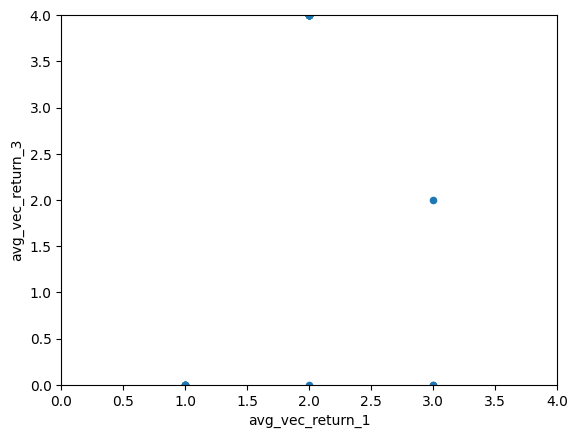

In [8]:
df.plot(kind='scatter', x='avg_vec_return_1', y='avg_vec_return_3', xlim=(0, 4), ylim=(0, 4))

In [ ]:
# pproximate Pareto front from a trained GPIPD/GPILS agent
from morl_baselines.common.evaluation import policy_evaluation_mo
from morl_baselines.common.weights import equally_spaced_weights
from morl_baselines.common.pareto import filter_pareto_dominated
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_WEIGHTS = 25
N_EPISODES_PER_WEIGHT = 5

returns = df.values

# Keep only non-dominated points (Pareto front approximation)
pareto_front = np.array(list(filter_pareto_dominated(returns)), dtype=np.float32)

print(f"Collected points: {len(returns)}")
print(f"Non-dominated points: {len(pareto_front)}")
print("Pareto front shape:", pareto_front.shape)

# Sort for cleaner plotting in 2D
if pareto_front.shape[1] == 2:
    pareto_front = pareto_front[np.argsort(pareto_front[:, 0])]

# Plot
if pareto_front.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(returns[:, 0], returns[:, 1], s=12, alpha=0.25, label="all eval points")
    plt.plot(pareto_front[:, 0], pareto_front[:, 1], "o-", color="black", label="pareto front")
    plt.xlabel("blue_triangle")
    plt.ylabel("red_triangle")
    plt.title("Approximated Pareto Front")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
elif pareto_front.shape[1] == 3:
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pareto_front[:, 0], pareto_front[:, 1], pareto_front[:, 2], s=20)
    ax.set_xlabel("objective_1")
    ax.set_ylabel("objective_2")
    ax.set_zlabel("objective_3")
    ax.set_title("Approximated Pareto Front")
    plt.show()
else:
    for i in range()

# Optional: save to CSV
# front_df = pd.DataFrame(pareto_front, columns=[f"objective_{i+1}" for i in range(pareto_front.shape[1])])
# front_df.to_csv("run_code/gpipd_pareto_front.csv", index=False)
# front_df.head()

Collected points: 25
Non-dominated points: 2
Pareto front shape: (2, 4)
Front has 4 objectives; skipping plot.


In [9]:
# Multi-policy returns visualization
# Loads all eval CSV files (one per training weight) and plots:
#   Plot 1 – Blue vs Red axes:      x = blue_triangle + blue_circle,  y = red_triangle + red_circle
#   Plot 2 – Circle vs Triangle axes: x = blue_circle + red_circle,  y = blue_triangle + red_triangle
#
# Marker shape encodes the training weight:
#   weight 0.0_1.0  (pure circle)   -> circle  'o'
#   weight 1.0_0.0  (pure triangle) -> triangle '^'
#   weights in between              -> intermediate markers
#
# Objective indices in the CSV:
#   avg_vec_return_0 = blue_triangle
#   avg_vec_return_1 = blue_circle
#   avg_vec_return_2 = red_triangle
#   avg_vec_return_3 = red_circle

import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def parse_training_weight(filename):
    """Return (triangle_weight, circle_weight) extracted from the filename."""
    base = os.path.basename(filename)
    match = re.search(r'weight_(\d+(?:\.\d+)?)_(\d+(?:\.\d+)?)', base)
    if match:
        return float(match.group(1)), float(match.group(2))
    raise ValueError(f"Filename does not match expected pattern: {filename}")

# Markers ordered from circle-like to triangle-like as triangle_weight increases
_MARKER_SEQUENCE = ['o', 'p', 'D', 's', '^']  # circle, square, diamond, pentagon, triangle

def weight_to_marker(triangle_weight, all_triangle_weights):
    """Map a triangle_weight value to a marker by rank among all weights."""
    sorted_weights = sorted(set(all_triangle_weights))
    n = len(sorted_weights)
    rank = sorted_weights.index(triangle_weight)
    # Map rank 0..(n-1) onto _MARKER_SEQUENCE
    if n == 1:
        return _MARKER_SEQUENCE[0]
    idx = round(rank / (n - 1) * (len(_MARKER_SEQUENCE) - 1))
    return _MARKER_SEQUENCE[idx]

# ---------------------------------------------------------------------------
# Load all CSV files
# ---------------------------------------------------------------------------

csv_pattern = os.path.join('eval_returns', 'eval_returns_my-four-room-*.csv')
csv_files = sorted(glob.glob(csv_pattern))

if not csv_files:
    # Fallback: notebook is run from inside eval_returns/
    csv_files = sorted(glob.glob('eval_returns_my-four-room*.csv'))

print(f'Found {len(csv_files)} CSV file(s):')
for f in csv_files:
    print(f'  {os.path.basename(f)}')

datasets = []
for filepath in csv_files:
    tw, cw = parse_training_weight(filepath)
    df_file = pd.read_csv(filepath)
    datasets.append({'df': df_file, 'triangle_weight': tw, 'circle_weight': cw})

# Sort by triangle_weight ascending (pure-circle first, pure-triangle last)
datasets.sort(key=lambda d: d['triangle_weight'])

all_tw = [d['triangle_weight'] for d in datasets]
for d in datasets:
    d['marker'] = weight_to_marker(d['triangle_weight'], all_tw)
    d['label'] = f"w=({d['triangle_weight']:.2f}\u25b3, {d['circle_weight']:.2f}\u25cb)"

print('\nDataset summary:')
for d in datasets:
    print(f"  {d['label']}  marker='{d['marker']}'  rows={len(d['df'])}")

Found 5 CSV file(s):
  eval_returns_my-four-room-v0__GPI-PD_weight_0.00_1.00__42__1777885103.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_0.25_0.75__42__1777890878.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_0.50_0.50__42__1777895969.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_0.75_0.25__42__1777902980.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_1.00_0.00__42__1777910770.csv

Dataset summary:
  w=(0.00△, 1.00○)  marker='o'  rows=25
  w=(0.25△, 0.75○)  marker='p'  rows=25
  w=(0.50△, 0.50○)  marker='D'  rows=25
  w=(0.75△, 0.25○)  marker='s'  rows=25
  w=(1.00△, 0.00○)  marker='^'  rows=25


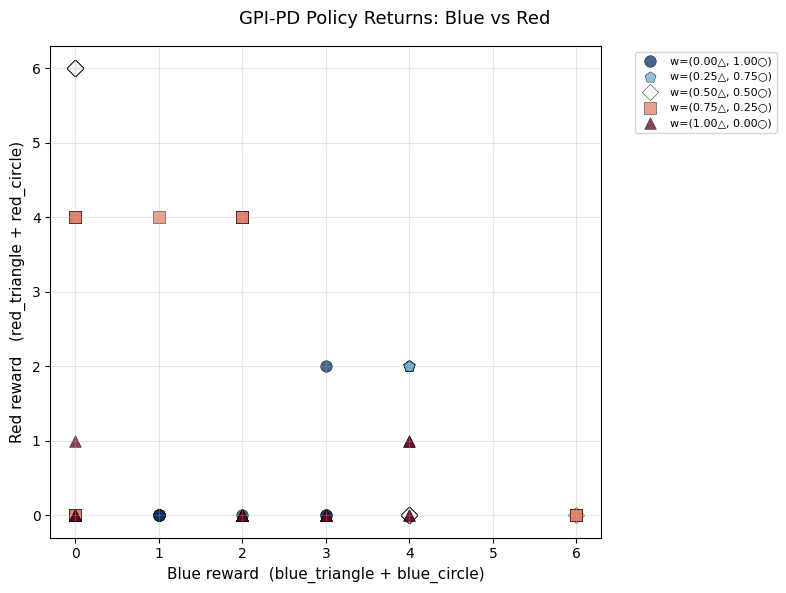

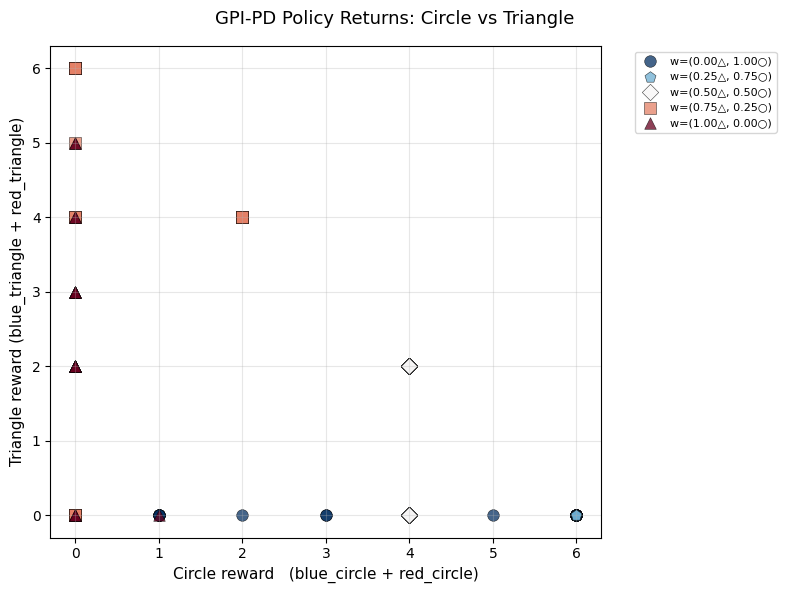

In [ ]:
# ---------------------------------------------------------------------------
# Two scatter plots: Blue/Red axes  and  Circle/Triangle axes (Separate figures)
# ---------------------------------------------------------------------------

# Color gradient: blue (pure-circle policy) -> red (pure-triangle policy)
cmap = plt.cm.RdBu_r
n = len(datasets)
colors = [cmap(i / max(n - 1, 1)) for i in range(n)]

fig1, ax1 = plt.subplots(figsize=(8, 6))
fig1.suptitle('GPI-PD Policy Returns: Blue vs Red', fontsize=13)

fig2, ax2 = plt.subplots(figsize=(8, 6))
fig2.suptitle('GPI-PD Policy Returns: Circle vs Triangle', fontsize=13)

for i, d in enumerate(datasets):
    df_d = d['df']
    marker = d['marker']
    label  = d['label']
    color  = colors[i]

    # --- Plot 1: Blue vs Red ---
    blue_reward     = df_d['avg_vec_return_0'] + df_d['avg_vec_return_1']  # blue_triangle + blue_circle
    red_reward      = df_d['avg_vec_return_2'] + df_d['avg_vec_return_3']  # red_triangle  + red_circle
    ax1.scatter(blue_reward, red_reward,
                    marker=marker, color=[color], label=label,
                    s=70, alpha=0.75, edgecolors='k', linewidths=0.4)

    # --- Plot 2: Circle vs Triangle ---
    circle_reward   = df_d['avg_vec_return_1'] + df_d['avg_vec_return_3']  # blue_circle   + red_circle
    triangle_reward = df_d['avg_vec_return_0'] + df_d['avg_vec_return_2']  # blue_triangle + red_triangle
    ax2.scatter(circle_reward, triangle_reward,
                    marker=marker, color=[color], label=label,
                    s=70, alpha=0.75, edgecolors='k', linewidths=0.4)

# --- Axis labels & styling ---
ax1.set_xlabel('Blue reward  (blue_triangle + blue_circle)', fontsize=11)
ax1.set_ylabel('Red reward   (red_triangle + red_circle)',   fontsize=11)
ax1.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Circle reward   (blue_circle + red_circle)',   fontsize=11)
ax2.set_ylabel('Triangle reward (blue_triangle + red_triangle)', fontsize=11)
ax2.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig(os.path.join('results/figures', 'policy_returns_blue_red.png'),
            dpi=150, bbox_inches='tight')

fig2.tight_layout()
fig2.savefig(os.path.join('results/figures', 'policy_returns_circle_triangle.png'),
            dpi=150, bbox_inches='tight')

plt.show()

In [2]:
import wandb
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def download_policy_returns(entity, project):
    # Initialize wandb API
    api = wandb.Api()
    
    # Calculate the timestamp for 2 days ago
    two_days_ago = datetime.now() - timedelta(days=2)
    
    # Fetch runs created in the last 2 days
    runs = api.runs(
        f"{entity}/{project}", 
        filters={"created_at": {"$gte": two_days_ago.isoformat()}}
    )
    
    # Ensure the output directory exists
    output_dir = "/eval_returns"
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"Found {len(runs)} runs from the past 2 days. Searching for 'policy_returns' tables...")
    
    for run in runs:
        try:
            # W&B Tables are saved as artifacts of type 'run_table'
            for artifact in run.logged_artifacts():
                if artifact.type == "run_table" and "policy_returns" in artifact.name:
                    print(f"Found table in run: {run.name}")
                    
                    # Download the artifact
                    artifact_dir = artifact.download()
                    
                    # The artifact contains a .table.json file with the columns and data
                    for file_name in os.listdir(artifact_dir):
                        if file_name.endswith('.table.json'):
                            file_path = os.path.join(artifact_dir, file_name)
                            
                            with open(file_path, 'r') as f:
                                table_data = json.load(f)
                            
                            # Convert the W&B table JSON into a pandas DataFrame
                            df = pd.DataFrame(
                                data=table_data["data"], 
                                columns=table_data["columns"]
                            )
                            
                            # Save to the requested output format
                            output_path = os.path.join(output_dir, f"eval_returns_{run.name}.csv")
                            df.to_csv(output_path, index=False)
                            print(f"Saved: {output_path}")
                            
        except Exception as e:
            print(f"Error processing run {run.name}: {e}")

# Replace with your W&B entity (username or team name) and project name
ENTITY = "kristofs-ai"
PROJECT = "MORL-Baselines"

download_policy_returns(ENTITY, PROJECT)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Found 9 runs from the past 2 days. Searching for 'policy_returns' tables...
Found table in run: my-four-room-v0__GPI-PD_weight_0.00_1.00__42__1777885103


wandb:   1 of 1 files downloaded.  


Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_0.00_1.00__42__1777885103.csv
Found table in run: my-four-room-v0__GPI-PD_weight_0.25_0.75__42__1777890878


wandb:   1 of 1 files downloaded.  


...

Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_0.50_0.50__42__1777895969.csv
Found table in run: my-four-room-v0__GPI-PD_weight_0.75_0.25__42__1777902980


wandb:   1 of 1 files downloaded.  


Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_0.75_0.25__42__1777902980.csv
Found table in run: my-four-room-v0__GPI-PD_weight_1.00_0.00__42__1777910770


wandb:   1 of 1 files downloaded.  


Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_1.00_0.00__42__1777910770.csv
